## LAB TASKS
1. Load a dataset for classification (e.g., Parkinson disease, Breast Cancer dataset).
2. Apply data preprocessing (handle missing values, encode categorical data).
3. Split the dataset into training and testing sets.
4. Apply Grid search to find the optimal parameters
5. Use those parameters to make predictions on the test set.
6. Evaluate performance using accuracy, precision, recall, and F1-score.
7. Visualize the Confusion Matrix
                  

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=["target"])
y = df["target"]
target_names = data.target_names  # 0: malignant, 1: benign

In [2]:
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

In [4]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)


In [6]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "criterion": ["gini", "entropy"],
}

In [7]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (F1): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Optimal Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Score (F1): 0.9738


In [8]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [9]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Test Set Performance ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


--- Test Set Performance ---
Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722
F1-Score:  0.9655

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



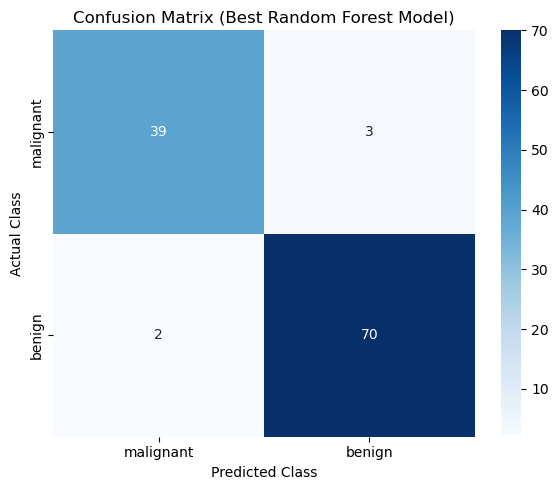

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix (Best Random Forest Model)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()